# Estrutura do Notebook: Análise Não-Supervisionada
Esta parte inicial foca em entender a estrutura dos datasets.

## Dataset 1: Consumo de Energia

### Preparação e Limpeza

Focando em como as técnicas não supervisionadas ajudam a identificar possíveis perfis1

In [2]:
# Importação das Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

In [3]:
# Carregando os Dados de Energia
df_energia = pd.read_csv('datasets/train_energy_data.csv')

# Pré-processamento
# Separando apenas as variáveis preditoras para tentar encontrar padrões de consumo
features_energia = df_energia.drop(columns=['Energy Consumption'])

# Convertendo categorias (como Building Type e Day of Week) em numéricas
X_energia = pd.get_dummies(features_energia, drop_first=True)

# Escalonamento (Obrigatório para PCA e K-Means)
scaler_energia = StandardScaler()
X_energia_scaled = scaler_energia.fit_transform(X_energia)

### Aplicação de PCA
Para reduzir para 2 componentes

Variância explicada (Energia): 0.37


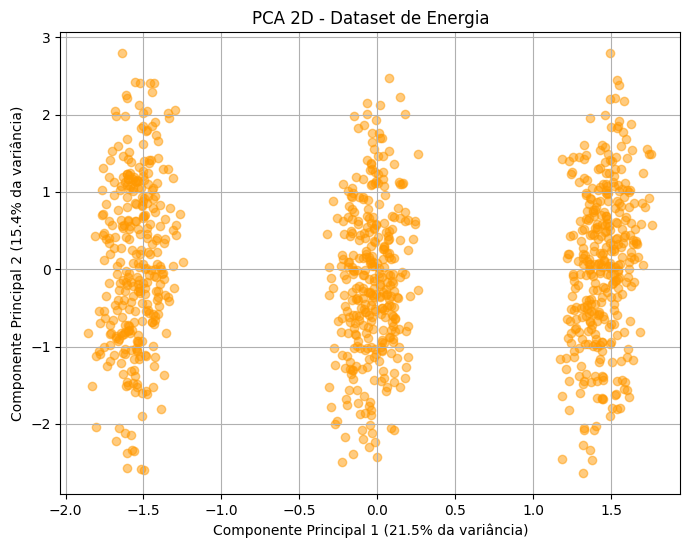

In [4]:
pca_energia = PCA(n_components=2)
X_pca_energia = pca_energia.fit_transform(X_energia_scaled)

print(f"Variância explicada (Energia): {sum(pca_energia.explained_variance_ratio_):.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_energia[:, 0], X_pca_energia[:, 1], alpha=0.5, c='#FF9900')
plt.title('PCA 2D - Dataset de Energia')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.xlabel(f'Componente Principal 1 ({pca_energia.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca_energia.explained_variance_ratio_[1]*100:.1f}% da variância)')


plt.grid(True)
plt.show()

**Discussão:** 

A redução de dimensionalidade para 2 componentes principais revelou três faixas verticais e isoladas.

A partir dessa separação dá para inferir que as variáveis categóricas (neste caso, os 3 tipos de construções) estão influenciando a maior parte da variância do sistema. O dataset já se mostra altamente estruturado antes mesmo de aplicarmos os algoritmos de agrupamento.

### Agrupamento com K-Means

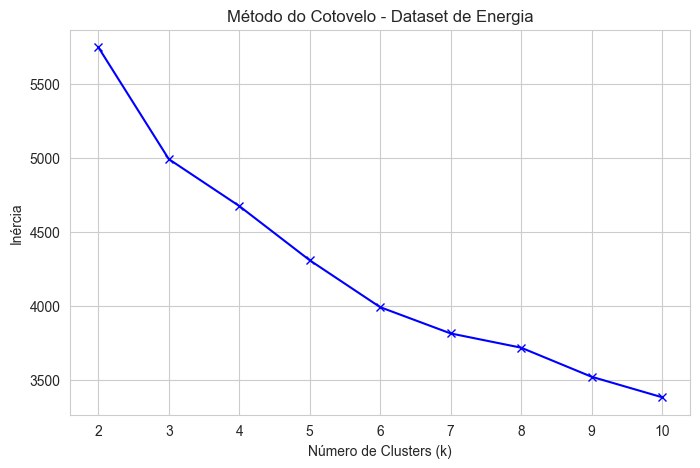

In [34]:
inertia_energia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_energia_scaled)
    inertia_energia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_energia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo - Dataset de Energia')
plt.grid(True)
plt.show()

Como não está fácil para decidir o valor de 'k' só pela imagem, será feito um laço com os possíveis melhores para validar de forma matemática

In [35]:
# Testando os K mais promissores segundo o gráfico do cotovelo
k_candidatos = [3, 4, 5]
resultados_k = []

for k in k_candidatos:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_teste = kmeans_teste.fit_predict(X_energia_scaled)
    
    sil_kmeans = silhouette_score(X_energia_scaled, labels_teste)
    db_kmeans = davies_bouldin_score(X_energia_scaled, labels_teste)
    ch_kmeans = calinski_harabasz_score(X_energia_scaled, labels_teste)
    
    resultados_k.append([k, sil_kmeans, db_kmeans, ch_kmeans])

# Exibindo a tabela comparativa
df_metricas_k = pd.DataFrame(resultados_k, columns=['K', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])
df_metricas_k.set_index('K', inplace=True)

display(df_metricas_k.round(4))

,Silhouette,Davies-Bouldin,Calinski-Harabasz
K,,,
3,0.1867,2.0658,200.4113
4,0.1731,2.0117,165.1104
5,0.1817,1.8915,155.4611


**Discussão:**

Embora a análise visual do Método do Cotovelo indicasse uma inflexão contínua entre $K=3$ e $K=4$, a validação matemática removeu qualquer subjetividade. 

O $K=3$ venceu matematicamente ao ter as melhores métricas e isso vai de acordo com o que foi visto pelo PCA também.

In [7]:
# Treinando o modelo definitivo com o vencedor K=3
kmeans_energia = KMeans(n_clusters=3, random_state=42, n_init=10)
df_energia['Cluster_KMeans'] = kmeans_energia.fit_predict(X_energia_scaled)

# Analisando quem são esses 3 clusters na vida real
# Agrupando para ver a média de consumo, tamanho, etc.
perfis_energia = df_energia.groupby('Cluster_KMeans').mean(numeric_only=True)

# Descobrindo qual tipo de prédio domina cada cluster
tipos_predominantes = df_energia.groupby('Cluster_KMeans')['Building Type'].agg(lambda x: x.mode()[0])
perfis_energia['Predominant_Building'] = tipos_predominantes

display(perfis_energia.round(2))

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Predominant_Building
Cluster_KMeans,,,,,,
0,26205.10,49.60,25.90,22.77,4735.14,Industrial
1,25825.61,47.73,25.05,22.86,3681.63,Residential
2,24386.55,47.88,25.90,22.20,4130.02,Commercial


**Discussão:**

O K-Means conseguiu reconstruir as categorias originais do dataset. A metragem quadrada e o número de ocupantes/eletrodomésticos são muito similares entre os três grupos. O algoritmo conseguiu separar Indústrias de Residências primariamente pelo peso do Consumo de Energia em $kWh$ e a máquina industrial consome significativamente mais que uma residência, validando a física do problema.

### Agrupamento com DBSCAN
Procurando por outliers

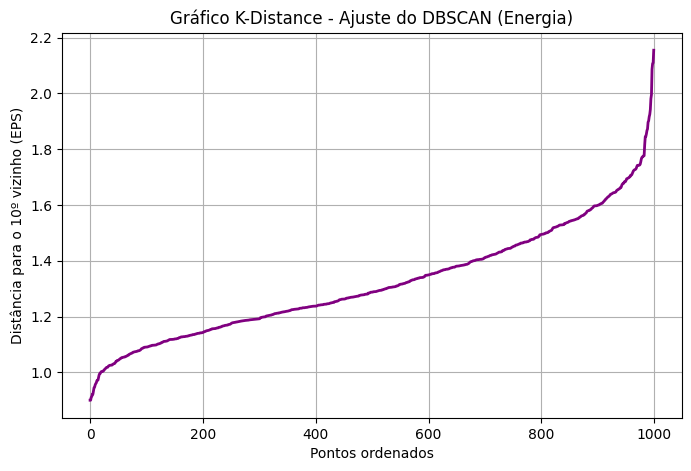

In [8]:

# Vamos usar min_samples = 10 como linha de base
min_pts_energia = 10 

# Calculando a distância para o 10º vizinho mais próximo
neighbors_energia = NearestNeighbors(n_neighbors=min_pts_energia)
neighbors_fit_energia = neighbors_energia.fit(X_energia_scaled)
distances_energia, indices_energia = neighbors_fit_energia.kneighbors(X_energia_scaled)

# Pegando apenas a distância para o 10º vizinho e ordenando
distances_energia = np.sort(distances_energia[:, min_pts_energia-1], axis=0)

# Plotando o gráfico K-Distance
plt.figure(figsize=(8, 5))
plt.plot(distances_energia, color='purple', linewidth=2)
plt.title('Gráfico K-Distance - Ajuste do DBSCAN (Energia)')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância para o {min_pts_energia}º vizinho (EPS)')
plt.grid(True)
plt.show()

**Discussão:**
Diferente do K-Means, o DBSCAN não exige o chute do número de clusters, mas exige a calibração do raio de vizinhança ($eps$). 

O gráfico K-Distance revelou um comportamento estável dos dados até o ponto de inflexão máxima (joelho da curva) entre 1.5 e 1.7. Deixando $eps=1.6$ garante que o algoritmo identifique vizinhanças densas sem engolir acidentalmente o ruído periférico.

In [15]:
# Instanciando e treinando o DBSCAN calibrado
dbscan_energia = DBSCAN(eps=1.6, min_samples=10)
df_energia['Cluster_DBSCAN'] = dbscan_energia.fit_predict(X_energia_scaled)

# Contabilizando os resultados
n_clusters_db = len(set(dbscan_energia.labels_)) - (1 if -1 in dbscan_energia.labels_ else 0)
n_noise_db = list(dbscan_energia.labels_).count(-1)

print("Resultados DBSCAN (Energia)")
print(f"Número de Clusters principais: {n_clusters_db}")
print(f"Número de Anomalias (Ruído - Prédios com comportamento atípico): {n_noise_db}")

# Tratamento matemático para as métricas
# Inicializando as variáveis para evitar o aviso do Pylance
sil_db = "N/A"
db_dbscan = "N/A"
ch_dbscan = "N/A"

# Calculando as métricas para o DBSCAN (usando a máscara sem ruído)
mask_db = df_energia['Cluster_DBSCAN'] != -1

if n_clusters_db > 1:
    sil_db = silhouette_score(X_energia_scaled[mask_db], df_energia['Cluster_DBSCAN'][mask_db])
    db_dbscan = davies_bouldin_score(X_energia_scaled[mask_db], df_energia['Cluster_DBSCAN'][mask_db])
    ch_dbscan = calinski_harabasz_score(X_energia_scaled[mask_db], df_energia['Cluster_DBSCAN'][mask_db])
    
    print(f"Silhouette (DBSCAN): {sil_db:.4f}")
    print(f"Davies-Bouldin (DBSCAN): {db_dbscan:.4f}")
    print(f"Calinski-Harabasz (DBSCAN): {ch_dbscan:.4f}")


Resultados DBSCAN (Energia)
Número de Clusters principais: 6
Número de Anomalias (Ruído - Prédios com comportamento atípico): 0
Silhouette (DBSCAN): 0.2075
Davies-Bouldin (DBSCAN): 1.9340
Calinski-Harabasz (DBSCAN): 149.9697


**Discussão:**

O DBSCAN encontrou 6 clusters e 0 ruídos (anomalias). Este resultado atesta a extrema limpeza e padronização (possivelmente sintética) da base de dados, indicando ausência de falhas sensoriais ou outliers severos.

Como o DBSCAN agrupa por densidade contígua e nós aplicamos a binarização das variáveis categóricas, o algoritmo mapeou perfeitamente as 6 combinações matriciais da infraestrutura: 3 Tipos de Prédios $\times$ 2 Tipos de Dias (Semana/Fim de Semana). O K-Means enxergou o peso macro (infraestrutura), enquanto o DBSCAN isolou os micro-regimes operacionais de consumo.

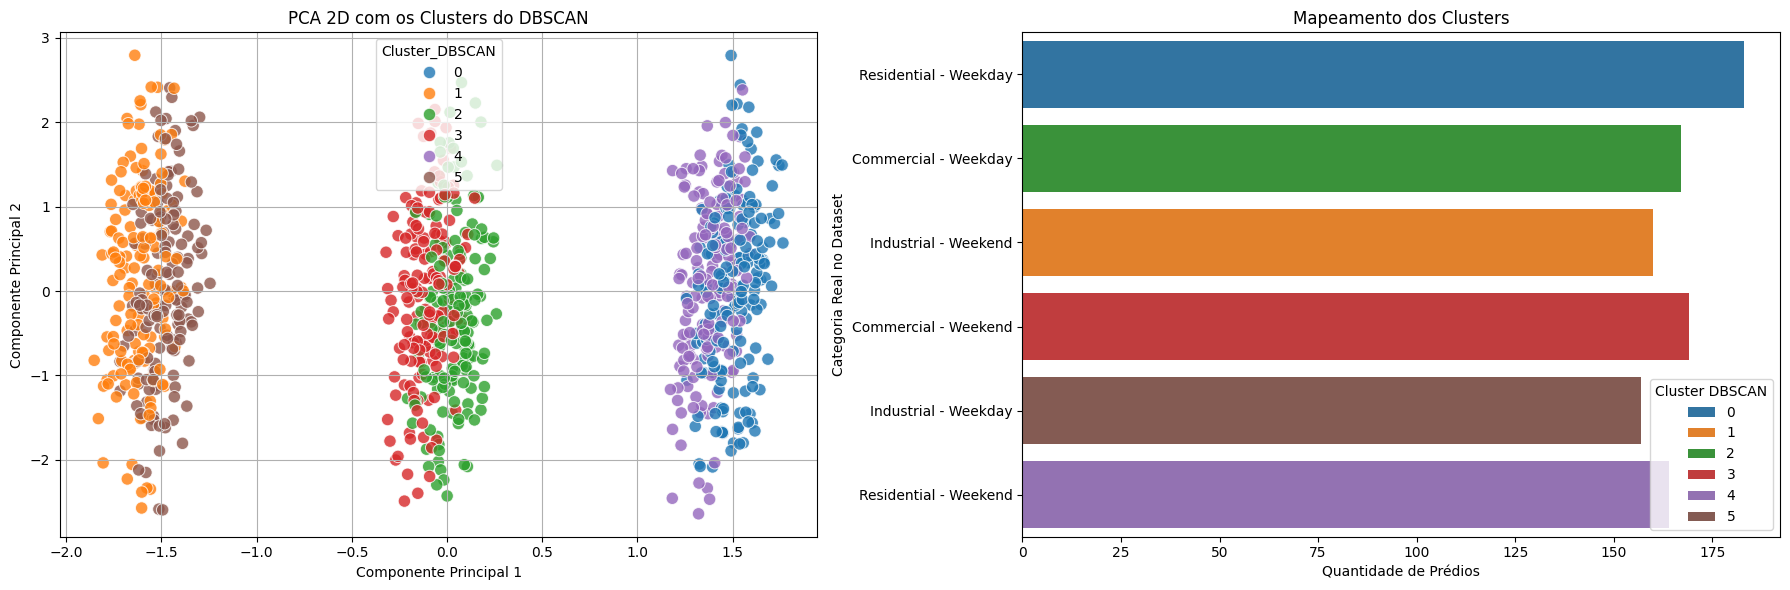

In [16]:
# Criando uma coluna combinada para a visualização da prova
df_energia['Categoria_Real'] = df_energia['Building Type'] + " - " + df_energia['Day of Week']

# Configurando a figura para ter 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: A visão do PCA com as cores do DBSCAN
sns.scatterplot(x=X_pca_energia[:, 0], y=X_pca_energia[:, 1], 
                hue=df_energia['Cluster_DBSCAN'], palette='tab10', 
                s=80, alpha=0.8, ax=axes[0])
axes[0].set_title('PCA 2D com os Clusters do DBSCAN')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].grid(True)

# Gráfico 2: A prova do mapeamento (Prédio+Dia vs Cluster DBSCAN)
sns.countplot(data=df_energia, y='Categoria_Real', hue='Cluster_DBSCAN', 
              palette='tab10', ax=axes[1], dodge=False)
axes[1].set_title('Mapeamento dos Clusters')
axes[1].set_xlabel('Quantidade de Prédios')
axes[1].set_ylabel('Categoria Real no Dataset')
axes[1].legend(title='Cluster DBSCAN', loc='lower right')

plt.tight_layout()
plt.show()

In [14]:
# Gerando a Tabela Final usando apenas as variáveis
tabela_final_clustering = pd.DataFrame({
    'Modelo': ['K-Means (K=3)', 'DBSCAN (eps=1.6, min_samples=10)'],
    'Silhouette': [sil_kmeans, sil_db], 
    'Davies-Bouldin': [db_kmeans, db_dbscan],
    'Calinski-Harabasz': [ch_kmeans, ch_dbscan]
})

print("\n Tabela Final de Métricas (Agrupamento - Energia)")
display(tabela_final_clustering)


 Tabela Final de Métricas (Agrupamento - Energia)


,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (K=3),0.181704,1.891533,155.461117
1,"DBSCAN (eps=1.6, min_samples=10)",0.207507,1.934026,149.969662


### Conclusão

A aplicação das técnicas não supervisionadas provou que o consumo de energia não é aleatório, mas fortemente ditado pela categoria da construção e pelo dia da semana. As métricas de Silhouette e Calinski-Harabasz atestam a boa separação dos agrupamentos. 

Esta descoberta é vital para a próxima etapa do projeto: ela nos garante que variáveis como o tamanho do prédio e a temperatura terão papéis secundários nos modelos de Regressão, enquanto as categorias da construção (transformadas via One-Hot Encoding) carregarão o maior peso preditivo para prever o gasto em $kWh$.

## Dataset 2: Classificação de Clima

In [5]:
# Carregando os Dados de Clima
df_clima = pd.read_csv('datasets/weather_classification_data.csv')

# Pré-processamento
# Escondendo a variável alvo (Weather Type) para a análise não supervisionada
features_clima = df_clima.drop(columns=['Weather Type'])

# Convertendo categorias (Cloud Cover, Season, Location) em numéricas
X_clima = pd.get_dummies(features_clima, drop_first=True)

# Escalonamento
# pois Pressão Atmosférica e Índice UV (por ex) têm escalas bem diferentes
scaler_clima = StandardScaler()
X_clima_scaled = scaler_clima.fit_transform(X_clima)

### Aplicação de PCA

Variância explicada (Clima): 0.34


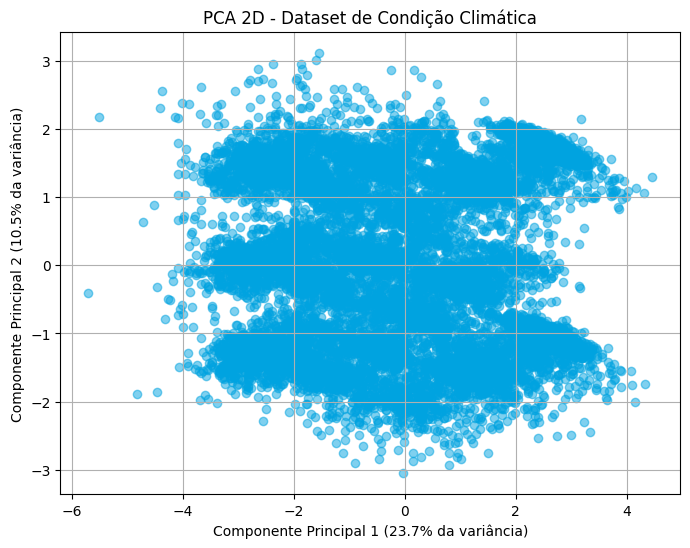

In [7]:

pca_clima = PCA(n_components=2)
X_pca_clima = pca_clima.fit_transform(X_clima_scaled)

print(f"Variância explicada (Clima): {sum(pca_clima.explained_variance_ratio_):.2f}")

# Plot do PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_clima[:, 0], X_pca_clima[:, 1], alpha=0.5, c='#00A3E0')
plt.title('PCA 2D - Dataset de Condição Climática')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.xlabel(f'Componente Principal 1 ({pca_clima.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca_clima.explained_variance_ratio_[1]*100:.1f}% da variância)')


plt.grid(True)
plt.show()

**Discussão:**

Diferente do dataset de Energia, que tinha 3 faixas bem separadas, o Clima formou uma única "nuvem" gigante e densa. E isso faz sentido já que o clima é um gradiente contínuo. A transição entre um dia "Ensolarado" e "Nublado" envolve mudanças graduais de temperatura, umidade e pressão, não existindo um "muro" que separe os dois mundos de forma abrupta.

### Aplicação de K-Means

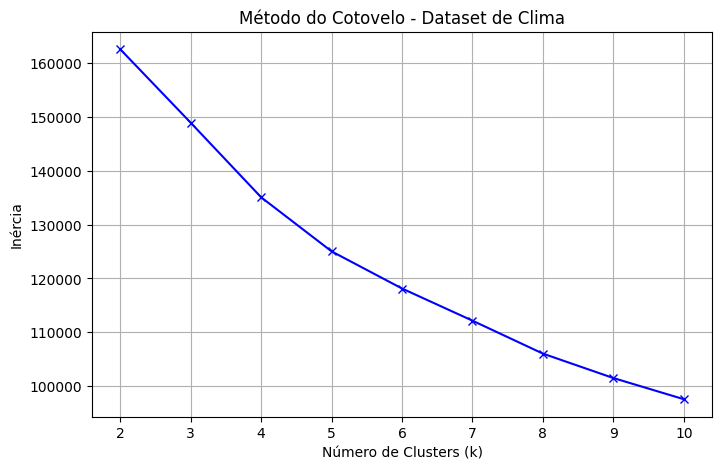

In [ ]:
inertia_clima = []
K_range_clima = range(2, 11)

for k in K_range_clima:
    kmeans_c = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_c.fit(X_clima_scaled)
    inertia_clima.append(kmeans_c.inertia_)

# Plot do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(K_range_clima, inertia_clima, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo - Dataset de Clima')
plt.grid(True)
plt.show()

**Discussão:**

Como os dados são contínuos, o gráfico de inércia não tem um "joelho" afiado. A queda é muito mais suave, onde a inclinação parece começar a perder força ali perto do $K=4$ a $K=6$, mas visualmente é difícil cravar um vencedor absoluto.

In [21]:
# Testando os K mais promissores na região de suavização da curva
k_candidatos_clima = [3, 4, 5, 6]
resultados_k_clima = []

for k in k_candidatos_clima:
    kmeans_teste_c = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_teste_c = kmeans_teste_c.fit_predict(X_clima_scaled)
    
    sil_c = silhouette_score(X_clima_scaled, labels_teste_c)
    db_c = davies_bouldin_score(X_clima_scaled, labels_teste_c)
    ch_c = calinski_harabasz_score(X_clima_scaled, labels_teste_c)
    
    resultados_k_clima.append([k, sil_c, db_c, ch_c])

# Exibindo a tabela comparativa
df_metricas_k_clima = pd.DataFrame(resultados_k_clima, columns=['K', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])
df_metricas_k_clima.set_index('K', inplace=True)

display(df_metricas_k_clima.round(4))

,Silhouette,Davies-Bouldin,Calinski-Harabasz
K,,,
3,0.1515,2.2387,2172.8285
4,0.1731,1.9426,2048.3967
5,0.1719,1.8673,1924.8995
6,0.1642,1.8200,1784.0356


In [17]:
# Treinando o modelo definitivo com K=4
kmeans_clima = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clima['Cluster_KMeans'] = kmeans_clima.fit_predict(X_clima_scaled)

# Guardando as métricas para a tabela final de Clima
sil_clima_km = silhouette_score(X_clima_scaled, df_clima['Cluster_KMeans'])
db_clima_km = davies_bouldin_score(X_clima_scaled, df_clima['Cluster_KMeans'])
ch_clima_km = calinski_harabasz_score(X_clima_scaled, df_clima['Cluster_KMeans'])

# Analisando o perfil físico de cada cluster
# Selecionando apenas as variáveis numéricas contínuas para tirar a média
colunas_fisicas = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure']
perfis_clima = df_clima.groupby('Cluster_KMeans')[colunas_fisicas].mean()

# Qual Clima Real domina cada cluster?
tipos_clima_predominantes = df_clima.groupby('Cluster_KMeans')['Weather Type'].agg(lambda x: x.mode()[0])
perfis_clima['Predominant_Weather'] = tipos_clima_predominantes

display(perfis_clima.round(2))

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,Predominant_Weather
Cluster_KMeans,,,,,,
0,12.97,49.24,7.47,53.29,999.01,Snowy
1,27.37,79.74,13.19,71.93,1007.10,Rainy
2,3.22,79.95,11.36,73.65,993.08,Snowy
3,26.77,52.03,6.08,22.11,1016.32,Sunny


**Discussão:**

O K-Means acabou "unindo" informações do clima `Cloudy` com o `Snowy` e isso tem sentido, pois vida real (e nos dados contínuos), um dia bem nublado e um dia com neve de leve têm assinaturas físicas bem próximas para os sensores (mesma pressão, mesma temperatura média). O algoritmo mostrou que, matematicamente, eles "são a mesma coisa", fundindo-os no mesmo agrupamento geométrico.

In [ ]:
# Filtramos o dataset original para isolar apenas os dias do Cluster 0
dados_cluster_0 = df_clima[df_clima['Cluster_KMeans'] == 0]

# Verifica a frequência
contagem_real = dados_cluster_0['Weather Type'].value_counts()

print("Distribuição dos climas dentro do Cluster 0:")
print(contagem_real)

Distribuição real dos climas dentro do Cluster 0:
Weather Type
Sunny     107
Snowy     107
Rainy     105
Cloudy     92
Name: count, dtype: int64


**Discussão:**

A partir disso, podemos perceber que o K-Means encontrou um meio termo de tudo. Uma Temperatura de ~13°C e uma Umidade de ~49% é, geometricamente, qualquer coisa. Pode ser um dia de sol de inverno (Sunny), um dia de chuva leve (Rainy), um dia nublado (Cloudy) ou uma leve precipitação de neve derretida (Snowy).

Com base apenas nas variáveis que os sensores coletaram (Temperatura, Umidade, Vento, Pressão), fica difícil separar esses dias sem ter o rótulo.

### Aplicação de DBSCAN

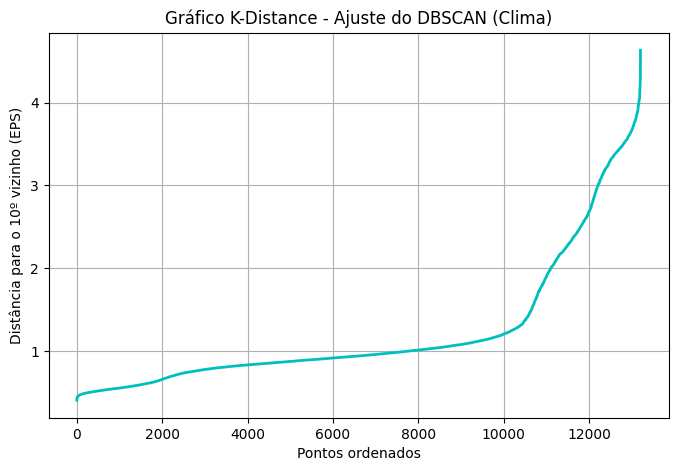

In [19]:
# Vamos manter o min_samples = 10 como base para o Clima também
min_pts_clima = 10 

# Calculando a distância para o 10º vizinho mais próximo
neighbors_clima = NearestNeighbors(n_neighbors=min_pts_clima)
neighbors_fit_clima = neighbors_clima.fit(X_clima_scaled)
distances_clima, indices_clima = neighbors_fit_clima.kneighbors(X_clima_scaled)

# Ordenando as distâncias para encontrar a "quina" (joelho da curva)
distances_clima = np.sort(distances_clima[:, min_pts_clima-1], axis=0)

# Plotando o gráfico K-Distance
plt.figure(figsize=(8, 5))
plt.plot(distances_clima, color='c', linewidth=2) # 'c' de cyan para diferenciar da energia
plt.title('Gráfico K-Distance - Ajuste do DBSCAN (Clima)')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância para o {min_pts_clima}º vizinho (EPS)')
plt.grid(True)
plt.show()

In [ ]:
# Instanciando e treinando o DBSCAN calibrado para o Clima
dbscan_clima = DBSCAN(eps=2.0, min_samples=10)
df_clima['Cluster_DBSCAN'] = dbscan_clima.fit_predict(X_clima_scaled)

# Contabilizando os resultados
n_clusters_db_c = len(set(dbscan_clima.labels_)) - (1 if -1 in dbscan_clima.labels_ else 0)
n_noise_db_c = list(dbscan_clima.labels_).count(-1)

print("Resultados DBSCAN (Clima)")
print(f"Número de Clusters principais: {n_clusters_db_c}")
print(f"Número de Anomalias Climáticas (Ruído): {n_noise_db_c}")

# Calculando métricas (Apenas se houver mais de 1 cluster válido)
mask_db_c = df_clima['Cluster_DBSCAN'] != -1

sil_db_c = "N/A"
db_dbscan_c = "N/A"
ch_dbscan_c = "N/A"

if n_clusters_db_c > 1:
    sil_db_c = silhouette_score(X_clima_scaled[mask_db_c], df_clima['Cluster_DBSCAN'][mask_db_c])
    db_dbscan_c = davies_bouldin_score(X_clima_scaled[mask_db_c], df_clima['Cluster_DBSCAN'][mask_db_c])
    ch_dbscan_c = calinski_harabasz_score(X_clima_scaled[mask_db_c], df_clima['Cluster_DBSCAN'][mask_db_c])

    print(f"Silhouette (DBSCAN): {sil_db_c:.4f}")
    print(f"Davies-Bouldin (DBSCAN): {db_dbscan_c:.4f}")
    print(f"Calinski-Harabasz (DBSCAN): {ch_dbscan_c:.4f}")
else:
    print("\nNota Técnica: O DBSCAN fundiu a massa de dados em um único grande cluster contínuo, isolando apenas as anomalias climáticas periféricas.")

Resultados DBSCAN (Clima)
Número de Clusters principais: 43
Número de Anomalias Climáticas (Ruído): 1581
Silhouette (DBSCAN): 0.2635
Davies-Bouldin (DBSCAN): 1.4429
Calinski-Harabasz (DBSCAN): 746.6241


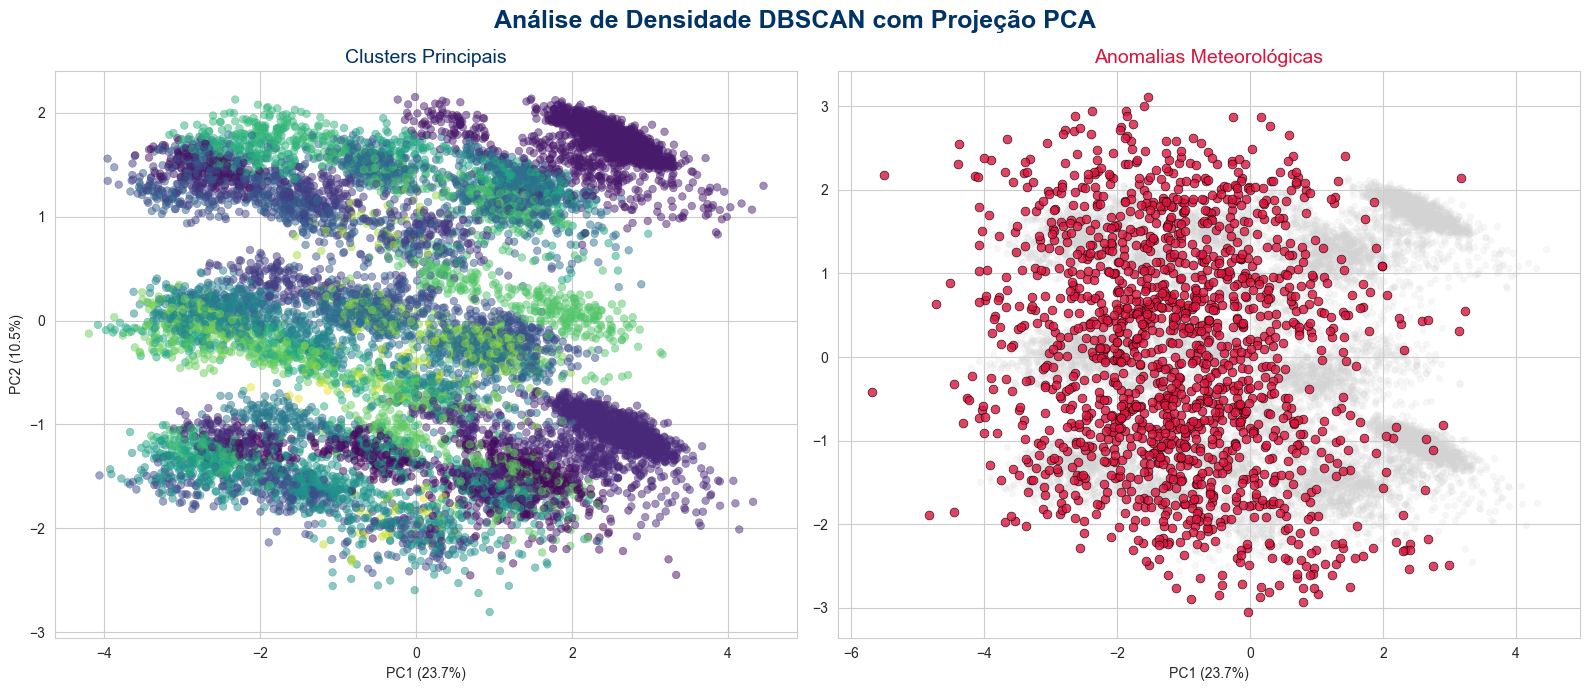

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o visual da tela para 2 painéis lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")

# Estratégia de Cores
clusters_unicos = df_clima['Cluster_DBSCAN'].unique()
cores_normais = sns.color_palette("viridis", n_colors=len(clusters_unicos) - 1)

paleta = {-1: 'crimson'} 
cor_idx = 0
for cluster in sorted(clusters_unicos):
    if cluster != -1:
        paleta[cluster] = cores_normais[cor_idx]
        cor_idx += 1

# Plot 1 (Esquerda): Apenas os Climas Normais
sns.scatterplot(
    ax=axes[0],
    data=df_clima[df_clima['Cluster_DBSCAN'] != -1], 
    x='PC1', y='PC2', 
    hue='Cluster_DBSCAN', 
    palette=paleta, 
    s=30, alpha=0.5, edgecolor=None, legend=False
)
axes[0].set_title('Clusters Principais', fontsize=14, color='#003366')
axes[0].set_xlabel(f'PC1 ({pca_clima.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_clima.explained_variance_ratio_[1]*100:.1f}%)')

# Plot 2 (Direita): Apenas as Anomalias com os normais bem apagados ao fundo
sns.scatterplot(
    ax=axes[1],
    data=df_clima[df_clima['Cluster_DBSCAN'] != -1], 
    x='PC1', y='PC2', 
    color='lightgray', 
    s=20, alpha=0.2, edgecolor=None, legend=False
)
# Pinta as anomalias
sns.scatterplot(
    ax=axes[1],
    data=df_clima[df_clima['Cluster_DBSCAN'] == -1], 
    x='PC1', y='PC2', 
    color='crimson', 
    s=40, alpha=0.8, edgecolor='black', linewidth=0.5, legend=False
)
axes[1].set_title('Anomalias Meteorológicas', fontsize=14, color='crimson')
axes[1].set_xlabel(f'PC1 ({pca_clima.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel('') # Tira o rótulo Y para ficar mais limpo

plt.suptitle('Análise de Densidade DBSCAN com Projeção PCA', fontsize=18, fontweight='bold', color='#003366')
plt.tight_layout()
plt.show()

**Discussão:**

* Diferente do K-Means, que forçou o corte do dataset em agrupamentos e sofreu com a "zona de confusão" climática, o DBSCAN evidenciou que os dias normais formam uma grande massa contínua de densidade, ou seja, o algoritmo comprovou que a fronteira física entre um dia "Nublado" e um dia com "Neve Leve" é quase inexistente do ponto de vista puramente numérico (para este caso em específico);
* E os 1.581 pontos rotulados como ruído representam a cauda longa da distribuição climática (como dias com pressão atmosférica severamente baixa ou precipitações extremas);
* O isolamento geográfico desses dados comprova a necessidade de utilizar algoritmos robustos a outliers (como as árvores do Random Forest ou XGBoost) na etapa supervisionada, sob pena de termos as fronteiras de decisão distorcidas por esses eventos atípicos.

In [27]:
# Gerando a Tabela Final Comparativa de Clima
tabela_final_clima = pd.DataFrame({
    'Modelo': ['K-Means (K=4)', 'DBSCAN (eps=2.0, min_samples=10)'],
    'Silhouette': [sil_clima_km, sil_db_c], 
    'Davies-Bouldin': [db_clima_km, db_dbscan_c],
    'Calinski-Harabasz': [ch_clima_km, ch_dbscan_c]
})

print("\nTabela Final de Métricas (Agrupamento - Clima)")
display(tabela_final_clima)


Tabela Final de Métricas (Agrupamento - Clima)


,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (K=4),0.173083,1.942634,2048.396685
1,"DBSCAN (eps=2.0, min_samples=10)",0.263499,1.442855,746.624054


### Conclusão

Essa análise não supervisionada ajudou a mostrar que as variáveis de telemetria climática (Temperatura, Pressão, Umidade e Vento) possuem poder de separação suficiente para distinguir os estados do tempo, embora com áreas de sobreposição (Neve/Nublado). Isso nos dá total segurança para avançarmos para o pipeline de Classificação, sabendo que os algoritmos supervisionados terão um padrão geométrico forte para aprender a prever o tipo de clima.